In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_curve, auc, classification_report)

In [2]:
# Plot Settings
sns.set_style('darkgrid')
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 14

In [3]:
# 1. Load Dataset
df = pd.read_csv('/content/heart.csv')

print("Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1025, 14)

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   

In [4]:
# 2. Data Cleaning
df.dropna(inplace=True)

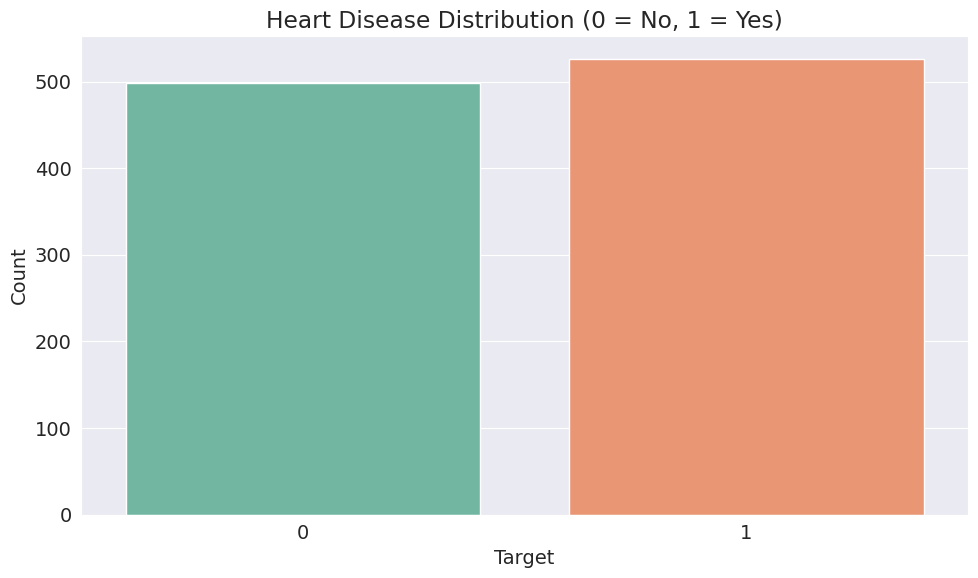

In [5]:
# 3. EDA — Target Distribution
plt.figure()
sns.countplot(data=df, x='target', palette='Set2', hue='target', legend=False)
plt.title('Heart Disease Distribution (0 = No, 1 = Yes)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

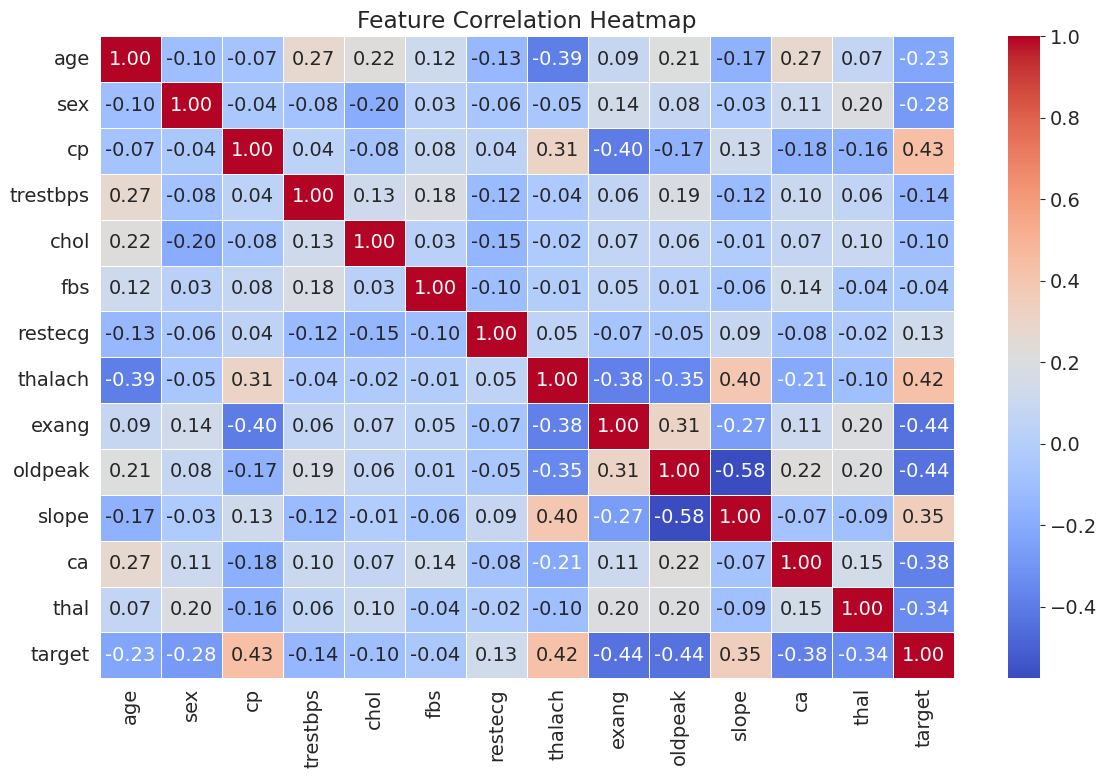

In [6]:
# 4. EDA — Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

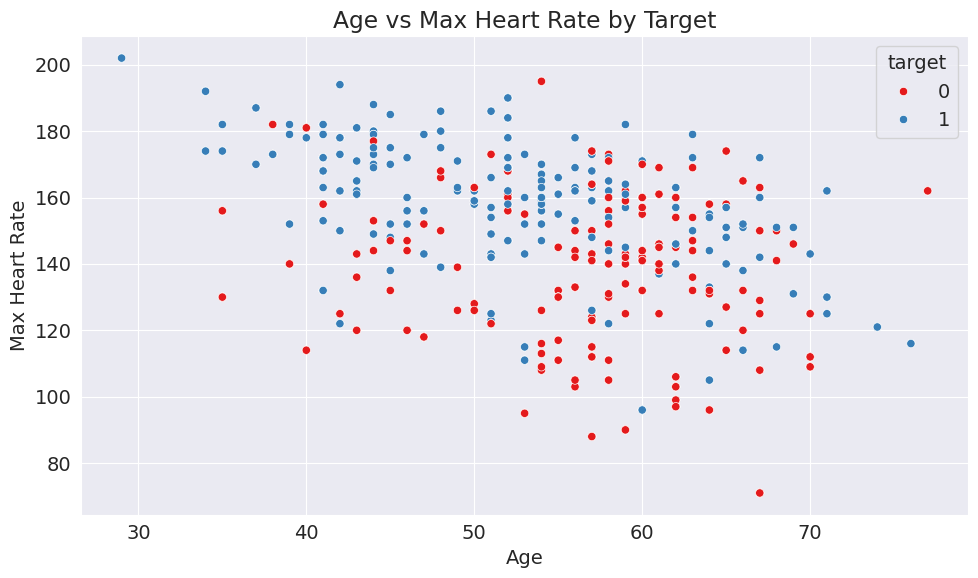

In [7]:
# 5. EDA — Age vs Max Heart Rate
plt.figure()
sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette='Set1')
plt.title('Age vs Max Heart Rate by Target')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.tight_layout()
plt.show()

In [8]:
# 6. Feature & Target Split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}, Testing samples: {len(X_test)}")


Training samples: 820, Testing samples: 205


In [9]:
# 7. Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
print(f"\nLogistic Regression Accuracy: {lr_acc * 100:.2f}%")
print(classification_report(y_test, lr_preds))


Logistic Regression Accuracy: 79.51%
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



In [10]:
# 8. Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)
print(f"Decision Tree Accuracy: {dt_acc * 100:.2f}%")
print(classification_report(y_test, dt_preds))

Decision Tree Accuracy: 98.54%
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



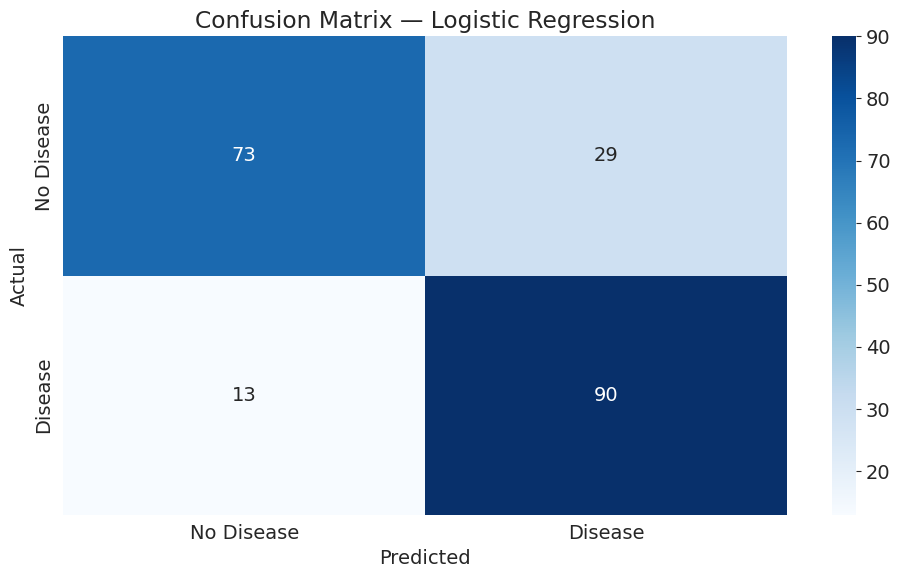

In [11]:
# 9. Confusion Matrix — Logistic Regression
plt.figure()
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

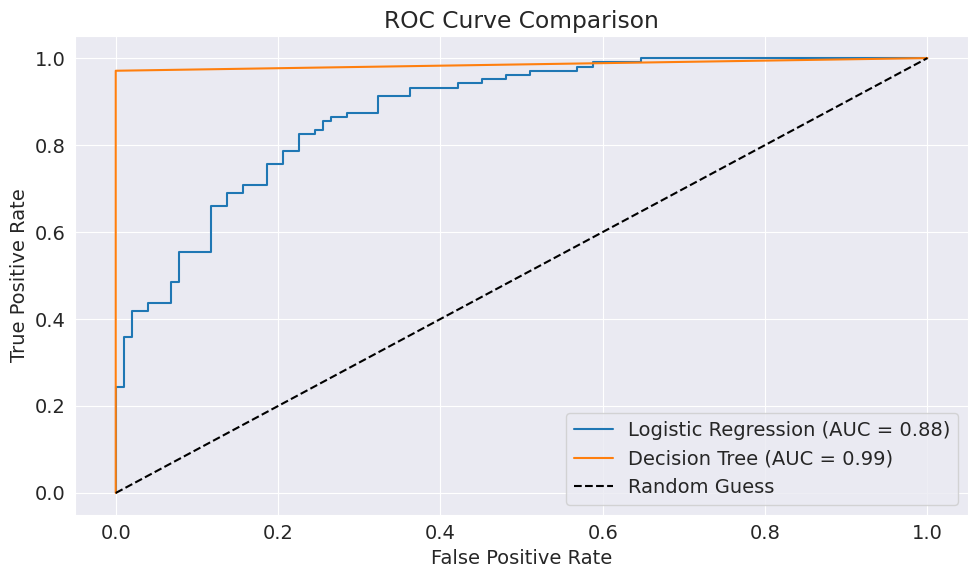

In [12]:
# 10. ROC Curve
plt.figure()
for model, name in [(lr_model, 'Logistic Regression'), (dt_model, 'Decision Tree')]:
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

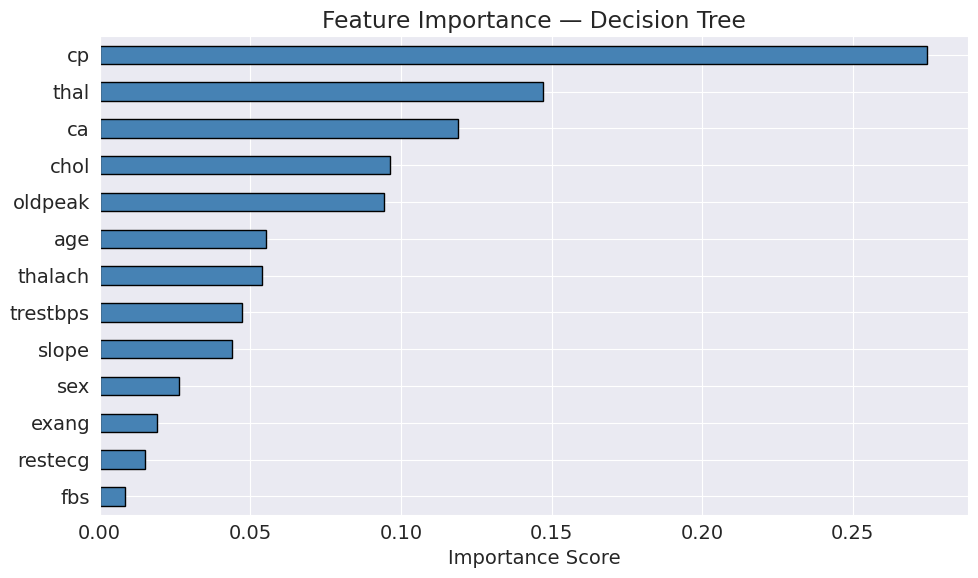

In [13]:
# 11. Feature Importance — Decision Tree
plt.figure()
importance = pd.Series(dt_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()